# Oscar — rough workings

My own working: things tried, dead ends, and code that may or may not make the
report. The unit reads this as evidence of contribution, so keep everything and
date it. It does not need to run top to bottom.

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
RAW = ROOT / "data" / "raw"

## 26 Sep 2026 — loading the Taiwan credit-card data

The file is already in `data/raw/` (notebook `report/01` downloads it). It is an
old-style Excel `.xls`, so pandas needs the `xlrd` package to read it. Row 0 of
the sheet is a title, so `header=1` tells pandas the column names are on the
second row. `index_col="ID"` uses the customer ID as the row label instead of
adding a 0, 1, 2... index.

In [4]:
taiwan = pd.read_excel(RAW / "taiwan-credit-default" / "default of credit card clients.xls",
                       header=1, index_col="ID")

print(taiwan.shape)   # (rows, columns) - expect (30000, 24)
taiwan.head()

(30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 26 Sep 2026 — rough EDA on the Taiwan data

First look: is the file clean, how common is default, do the columns hold the
values the UCI description says they should, and which columns look related to
default? Uses `taiwan` from the cell above.

In [5]:
# The label's name is long, so give it a short alias.
Y = "default payment next month"

# Are any values missing? Are any rows exact copies of another row?
print("missing values:", taiwan.isna().sum().sum())
print("duplicate rows:", taiwan.duplicated().sum())
taiwan.dtypes.value_counts()   # what types pandas gave the columns

missing values: 0
duplicate rows: 35


int64    24
Name: count, dtype: int64

`duplicated()` compares whole rows *ignoring the ID* (the ID is the index, not
a column), so a duplicate here means two customers with identical values in all
24 columns. Worth asking: same person entered twice, or genuinely identical?

In [6]:
# How common is default? normalize=True gives proportions instead of counts.
taiwan[Y].value_counts(normalize=True)

default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

### Do the codes match the documentation?

The UCI page says: `EDUCATION` 1 = graduate school, 2 = university,
3 = high school, 4 = others. `MARRIAGE` 1 = married, 2 = single, 3 = others.
`PAY_*` -1 = paid on time, 1 = one month late, 2 = two months late, ... up to
9. `sort_index()` lists the values in order so unexpected ones stand out.

In [7]:
for col in ["SEX", "EDUCATION", "MARRIAGE", "PAY_0"]:
    print(col, taiwan[col].value_counts().sort_index().to_dict())

SEX {1: 11888, 2: 18112}
EDUCATION {0: 14, 1: 10585, 2: 14030, 3: 4917, 4: 123, 5: 280, 6: 51}
MARRIAGE {0: 54, 1: 13659, 2: 15964, 3: 323}
PAY_0 {-2: 2759, -1: 5686, 0: 14737, 1: 3688, 2: 2667, 3: 322, 4: 76, 5: 26, 6: 11, 7: 9, 8: 19}


In [8]:
# Summary statistics for the money columns and age.
taiwan[["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]].describe().round(0)

,LIMIT_BAL,AGE,BILL_AMT1,PAY_AMT1
count,30000.0,30000.0,30000.0,30000.0
mean,167484.0,35.0,51223.0,5664.0
std,129748.0,9.0,73636.0,16563.0
min,10000.0,21.0,-165580.0,0.0
25%,50000.0,28.0,3559.0,1000.0
50%,140000.0,34.0,22382.0,2100.0
75%,240000.0,41.0,67091.0,5006.0
max,1000000.0,79.0,964511.0,873552.0


### Which columns relate to default?

`groupby(col)[Y].mean()` splits the customers by each value of `col`, then
takes the mean of the 0/1 label in each group. The mean of a 0/1 column is the
proportion of 1s, so this is the **default rate** for each group.

Colours in the plots: blue for no default, orange for default, used the same
way in every plot. The grey dashed line is the overall default rate.

In [9]:
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#8a8984"   # no default, default, reference lines
overall = taiwan[Y].mean()

by_pay = taiwan.groupby("PAY_0")[Y].agg(rate="mean", customers="size")
by_pay   # customers = how many people are in each group

,rate,customers
PAY_0,,
-2,0.132294,2759
-1,0.167781,5686
0,0.128113,14737
1,0.339479,3688
2,0.691414,2667
3,0.757764,322
4,0.684211,76
5,0.500000,26
6,0.545455,11


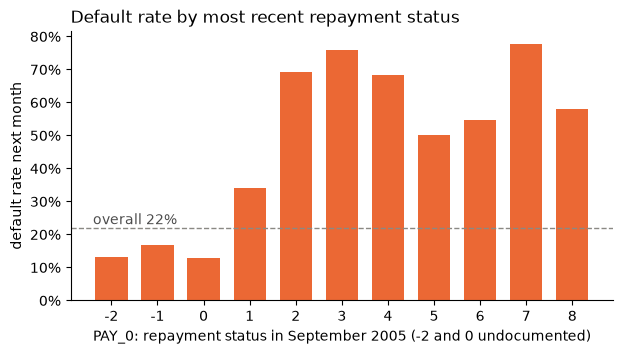

In [10]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(by_pay.index.astype(str), by_pay["rate"], color=ORANGE, width=0.7)
ax.axhline(overall, color=GREY, linestyle="--", linewidth=1)
ax.text(-0.4, overall, f"overall {overall:.0%}", va="bottom", ha="left", color="0.3")
ax.set_xlabel("PAY_0: repayment status in September 2005 (-2 and 0 undocumented)")
ax.set_ylabel("default rate next month")
ax.set_title("Default rate by most recent repayment status", loc="left")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

Groups 3-8 are small (under 350 people each, see `customers` above), so
their rates are noisy. Do not read much into the differences between them.

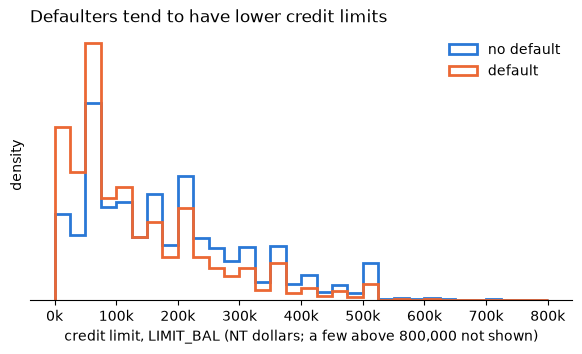

default payment next month
0    150000.0
1     90000.0
Name: LIMIT_BAL, dtype: float64

In [11]:
# Credit limit, for people who did and didn't default.
# density=True scales each histogram to area 1, so the two groups can be
# compared even though there are about 3.5 times more non-defaulters.
fig, ax = plt.subplots(figsize=(7, 3.5))
bins = np.arange(0, 800_001, 25_000)
for value, colour, label in [(0, BLUE, "no default"), (1, ORANGE, "default")]:
    ax.hist(taiwan.loc[taiwan[Y] == value, "LIMIT_BAL"], bins=bins, density=True,
            histtype="step", linewidth=2, color=colour, label=label)
ax.set_xlabel("credit limit, LIMIT_BAL (NT dollars; a few above 800,000 not shown)")
ax.set_ylabel("density")
ax.set_title("Defaulters tend to have lower credit limits", loc="left")
ax.xaxis.set_major_formatter(lambda v, _: f"{v/1000:.0f}k")
ax.set_yticks([])   # density values have no useful meaning on their own
ax.legend(frameon=False)
ax.spines[["top", "right", "left"]].set_visible(False)
plt.show()

taiwan.groupby(Y)["LIMIT_BAL"].median()

### Notes so far (rough)

* No missing values. 35 rows duplicate another row: check before modelling.
* 22% default, so a model that always says "no default" is already 78%
  accurate. Accuracy is a poor measure here, which is a point for notebook 04.
* Undocumented codes: `EDUCATION` has 0, 5 and 6; `MARRIAGE` has 0; `PAY_*` has
  -2 and 0. Next: find what other people assume they mean (Kaggle notebooks,
  papers that use this data) and cite it.
* `PAY_0` is by far the clearest signal: being 2 or more months late now means
  roughly a 70% default rate, against 13% for 0.
* Defaulters have a lower median credit limit (90k vs 150k).
* Some `BILL_AMT` values are negative (about 600 per month): probably overpaid
  credit? Check.

**To try next:** default rate by `EDUCATION`, `SEX`, `AGE` band; how the
`PAY_*` columns relate to each other across the six months; do the same for
German Credit.